# Bachelor Project

This is the main file for Dennis Mitzeus' bachelor thesis project. The project includes data preprocessing, project structuring, technical implementation, and evaluation.

The current Architecture looks like this:

<img width="400px" src="./figures/artifact_flowchart_new.png"></img>

## Structure

This project will go through

1. Data Preprocessing
2. API setup
3. Technical Implementation
4. Evaluation

## Project

In [329]:
# Import Declarations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing

#### Status for language Datasets Found:
* ✅ Swedish
* ❌ Spanish
* ✅ Korean

#### Dataset explanations

##### Swedish

The Swedish dataset "Kelly" is used for Swedish. Swedish dataset contains 9 columns: "ID", "Raw freq", "WPM" "CEFR levels", "Source", "Grammar", "Swedish items for translation", "Word classes", and "Examples". 

Raw freq corresponds to the total frequency over the whole extracted corpus, WPM corresponds to a ratio of how many words per 1 000 000 words is this word, CEFR levels correspond to how advanced a word is following the Common European Framework of Reference for Languages, Source is from which corpus the word comes from, Grammar corresponds to certain prefixes or suffixes some word classes inherit (for example "att" before all root verbs), Swedish items for translation is the word itself, word classes correspond to which grammatical type a word is (more details under "Lookup" workspace in file datasets/1-raw/swedish.xls), lastly, examples provide example sentences of use for some words.

##### Korean

Korean dataset is from the National Korean Language Institute which is a put together list of the most common words in the Korean language for foreign learners practicing for the TOPIK (Test of Proficiency in Korean) test. Korean dataset contains 5 columns: "순위", "단어", "품사", "풀이", and "등급".

순위 corresponds to the frequency ranking based on a 2002 researcher report named "Survey on Modern Korean Usage Frequency", 단어 corresponds to the word itself, 품사 refers to the grammatical type a word is (more details can be found at [the official dataset site](https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)),풀이 refers to the Hanja (漢字) versions of some words, and 등급 refers to which TOPIK level a word is in where A means basic B is intermediate and C is advanced level.

##### Spanish

?

### Preprocessing based on some criteria

For our preprocessing we need to fulfill some critera to get a good subset of the datasets viable for testing in the thesis architecture. 

It requires:

1. Vocabulary list of 100 Words per Language
2. A varied set of grammar types (Nouns, Verbs etc.), some weight more than others such as verbs being more important than conjunctions for basic language.
3. The words should be the most common in most cases. This means relative frequency is better than raw frequency.

#### Batches

Batches are subsets of a final dataset for gradual introduction into the thesis architecture system and works similar to smaller independent datasets inside the bigger one, meaning each batch will have similar word type ratios and not purely based on commonality (in case of a vocabulary list of 100 words, most adjectives may be top 60 meaning no adjectives can ever be used until batches after top 60 gets introduced)

This is a visual image of batches: 

<img src="./figures/flashcard_batches.png" width="400px"></img>

### Preprocessing

#### Swedish

In [330]:
# removing NaN's
swedish_raw = pd.read_csv("datasets/2-extracted/swedish.csv", sep=";") # import

# drop rows with NaN's for all necessary features
swedish_dropped_nas = swedish_raw.dropna(axis=0, subset=["WPM", "CEFR levels", "Swedish items for translation", "Word classes"])

table_stats_dropped = pd.DataFrame(columns=["Nr of NaN Before", "Nr of NaN After"])

table_stats_dropped["Nr of NaN Before"] = swedish_raw.isna().sum().to_list()
table_stats_dropped["Nr of NaN After"] = swedish_dropped_nas.isna().sum().to_list()
table_stats_dropped.index = swedish_dropped_nas.columns

display(table_stats_dropped)

print(f"Total Nr of Entries Before: {len(swedish_raw)}")
print(f"Total Nr of Entries After: {len(swedish_dropped_nas)}")

,Nr of NaN Before,Nr of NaN After
ID,0,0
Raw freq,2650,2650
WPM,0,0
CEFR levels,0,0
Source,0,0
Grammar,2841,2841
Swedish items for translation,0,0
Word classes,0,0
Examples,8180,8180


Total Nr of Entries Before: 8425
Total Nr of Entries After: 8425


In [331]:
# changing WPM to numeric
swedish_dropped_nas["WPM"] = swedish_dropped_nas["WPM"].str.replace(",", ".").astype("Float64")

# drop rows with super high WPM values (outliers)
swedish_dropped_nas = swedish_dropped_nas[swedish_dropped_nas["WPM"] < 1000000]

In [332]:
# Removing unnecessary word classes and clumping similar word classes together

swedish_dropped_nas["Word classes"].unique() # finding all unique word classes

# exclude unnecessary word classes
unnecessary_word_classes = ["numeral", "proper name", "particip"]

swedish_word_classes_excluded = swedish_dropped_nas[~swedish_dropped_nas["Word classes"].isin(unnecessary_word_classes)]

# clump similar word classes together, (e.g. all nouns together, verbs together etc.)
clump_word_classes = {
    "noun": ["noun", "noun-en", "noun-ett", "noun-en/-ett"],
    "verb": ["verb", "aux verb"]
}

word_types = swedish_word_classes_excluded["Word classes"]

for word_type, word_class_list in clump_word_classes.items(): # clumping word classes together
    word_types = word_types.replace(word_class_list, word_type)

swedish_clumped = swedish_word_classes_excluded.copy()
swedish_clumped["Word classes"] = word_types

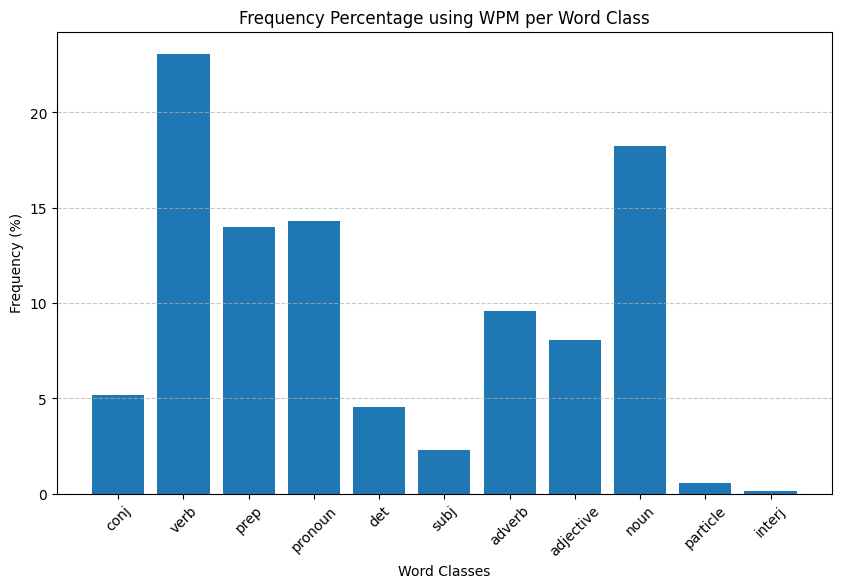

In [340]:
# Figuring out frequency of each word class using WPM 

# calculate the sum of all WPM and for each to get weighted percentages
total_wpm = swedish_clumped["WPM"].sum()

percentages = []

for word_type in swedish_clumped["Word classes"].unique():

    word_type_wpm = swedish_clumped[swedish_clumped["Word classes"] == word_type]["WPM"].sum()

    percentage = (word_type_wpm / total_wpm) * 100
    percentages.append(percentage)


plt.figure(figsize=(10, 6))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar(swedish_clumped["Word classes"].unique(), percentages)
# plt.figsize = (10, 6)
plt.xlabel("Word Classes")
plt.ylabel("Frequency (%)")
plt.title("Frequency Percentage using WPM per Word Class")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Building final dataset

# Calculate discrete amounts based on percentages






# divide into batches for dataset assembly

#### Korean

In [334]:
# TODO Korean

#### Spanish

In [335]:
# TODO Spanish

### API Setup

### Technical Implementation

### Evaluation